# Differential Accessibility in WT along trajectories

In [2]:
## Load packages
suppressPackageStartupMessages(library(destiny))
suppressPackageStartupMessages(library(tradeSeq))
suppressPackageStartupMessages(library(slingshot))
suppressPackageStartupMessages(library(BiocParallel))
suppressPackageStartupMessages(library(ArchR))
suppressPackageStartupMessages(library(dplyr))

here::i_am("rna_atac/trajectory/02_ATAC_WT_trajectory_markers.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

# Options
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16
addArchRThreads(24)
set.seed(6)

## I/O
args = list()
# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated.txt.gz')
# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')
# Archr
args$archr_directory = file.path(io$basedir, 'processed/atac/archR')
args$peakmtx = file.path(io$basedir, 'processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds')
# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/trajectory/')
# Slingshot
args$slingshot = file.path(args$outdir, 'slingshot.rds')

## Load data
print('loading data')
# Load meta
meta = fread(args$metadata)[day%in%c('D3.5', 'D4', 'D4.5', 'D5')] # & genotype=='WT']
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

# load slingshot
slingshot = readRDS(args$slingshot)
pseudotime = slingPseudotime(slingshot, na=F)

# Load Tradeseq differential genes
tradeseq_results = fread(paste0(args$outdir,"/tradeseq_results.txt.gz"))

## Subset Cells
print('Subsetting cells')
# Keep only WT cells
sce_filt = rna.sce[,colData(rna.sce)$genotype == 'WT']
slingshot = slingshot[colnames(sce_filt),]
pseudotime = pseudotime[colnames(sce_filt),]

# Only keep YS vs Allantois trajectory
slingshot = slingshot[,c(2,3)]
pseudotime = pseudotime[,c(2,3)]

# Subset to cells within one of the trajectories
cells_keep = ifelse(pathStats(slingshot)$weights[,1] == 0 & pathStats(slingshot)$weights[,2] == 0, FALSE, TRUE)
slingshot = slingshot[cells_keep,]
sce_filt = sce_filt[, cells_keep]
pseudotime = pseudotime[cells_keep,]

# Adjust pseudotime to match between the two lineages
pseudodifference = as.data.table(slingPseudotime(slingshot)) %>% .[,diff:=Lineage3-Lineage2]
pseudotime[,2] = pseudotime[,2] - mean(pseudodifference$diff, na.rm=T)

# Minmax normalise both pseudotimes so they range from 0 to 1
minmax = function(x){(x-min(x))/(max(x)-min(x))}
pseudotime[,1] = minmax(pseudotime[,1])
pseudotime[,2] = minmax(pseudotime[,2])


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

[1] "loading data"


Loading required package: scuttle


Attaching package: ‘scran’


The following object is masked from ‘package:TrajectoryUtils’:

    createClusterMST




[1] "Subsetting cells"


In [3]:
# Load meta
meta = fread(args$metadata)[genotype=='WT']

#### Load Data

In [4]:
ArchRProject <- loadArchRProject(args$archr_directory)[meta$cell]

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [5]:
ArchRProject <- addCellColData(ArchRProj = ArchRProject, 
                                    data = as.character(meta$celltype_v1),
                                    cells = meta$cell,
                                    name = "celltype_v1",
                                    force=TRUE)

In [6]:
# Load ATAC data
atac.sce = readRDS(args$peakmtx)[,meta$cell]
colData(atac.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [7]:
# Assign cells to lineage
set.seed(6)
Traj_assignment = as.data.table(tradeSeq:::.assignCells(assays(slingshot)$weights), keep.rownames=T) %>%
    setnames(c('cell', 'Trajectory1', 'Trajectory2'))

Traj1 = as.data.table(pseudotime[,1], keep.rownames=T) %>% 
    .[V1 %in% Traj_assignment[Trajectory1 == 1, cell]] #%>% 
   # .[V2>5 & V2<10]

Traj2 = as.data.table(pseudotime[,2], keep.rownames=T) %>% 
    .[V1 %in% Traj_assignment[Trajectory2 == 1, cell]] #%>% 
    #.[V2>5 & V2<10]

# Combine & add which trajectory
Traj_full = rbind(Traj1[,Traj:='YS_Traj'], Traj2[,Traj:='Allantois_Traj']) %>%
    setnames(c('cell', 'pseudotime', 'Traj'))

### ChromVAR of differential TFs along trajectories

In [99]:
silicoCISBP = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "silicoChIP_CISBPMatrix",
  useSeqnames = 'z',
  verbose = FALSE)

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-581fe14ebab17-Date-2023-12-11_Time-18-38-34.log
If there is an issue, please report to github with logFile!



In [100]:
# TFs in tradeseq_results
tradeseq_TFs = tradeseq_results %>% copy() %>% 
    .[sig==TRUE] %>% 
    .[gene %in% str_to_title(rownames(silicoCISBP))]

silicoCISBP_filt = silicoCISBP[str_to_upper(tradeseq_TFs$gene)]

In [101]:
# Get ChromVAR along trajectories
silicoCISBP_filt.dt = as.data.table(t(as.matrix(assay(silicoCISBP_filt))),keep.rownames=T) %>% 
    setnames('rn', 'cell') %>% 
    merge(., Traj_full, by='cell') %>%  # Add pseudotime & trajectory
    melt(., id.vars = c("cell", "pseudotime", "Traj"), # wide to long
               variable.name = "gene", value.name = "ChromVAR_score")

In [74]:
length(unique(silicoCISBP_filt.dt$gene))

[1] 27

In [75]:
options(repr.plot.height=5, repr.plot.width=6)
plot_chromVAR = function(TF){
    p = ggplot(silicoCISBP_filt.dt[gene==TF], aes(pseudotime, ChromVAR_score, color=Traj)) + 
        geom_point(size=0.2, alpha=0.2) + 
        scale_color_manual(values=c(YS_Traj='black', Allantois_Traj='red'), name='Trajectory') + 
        geom_smooth() +
        ggtitle(TF) + 
        theme_bw()
}

plot_list = lapply(unique(silicoCISBP_filt.dt$gene), plot_chromVAR)

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


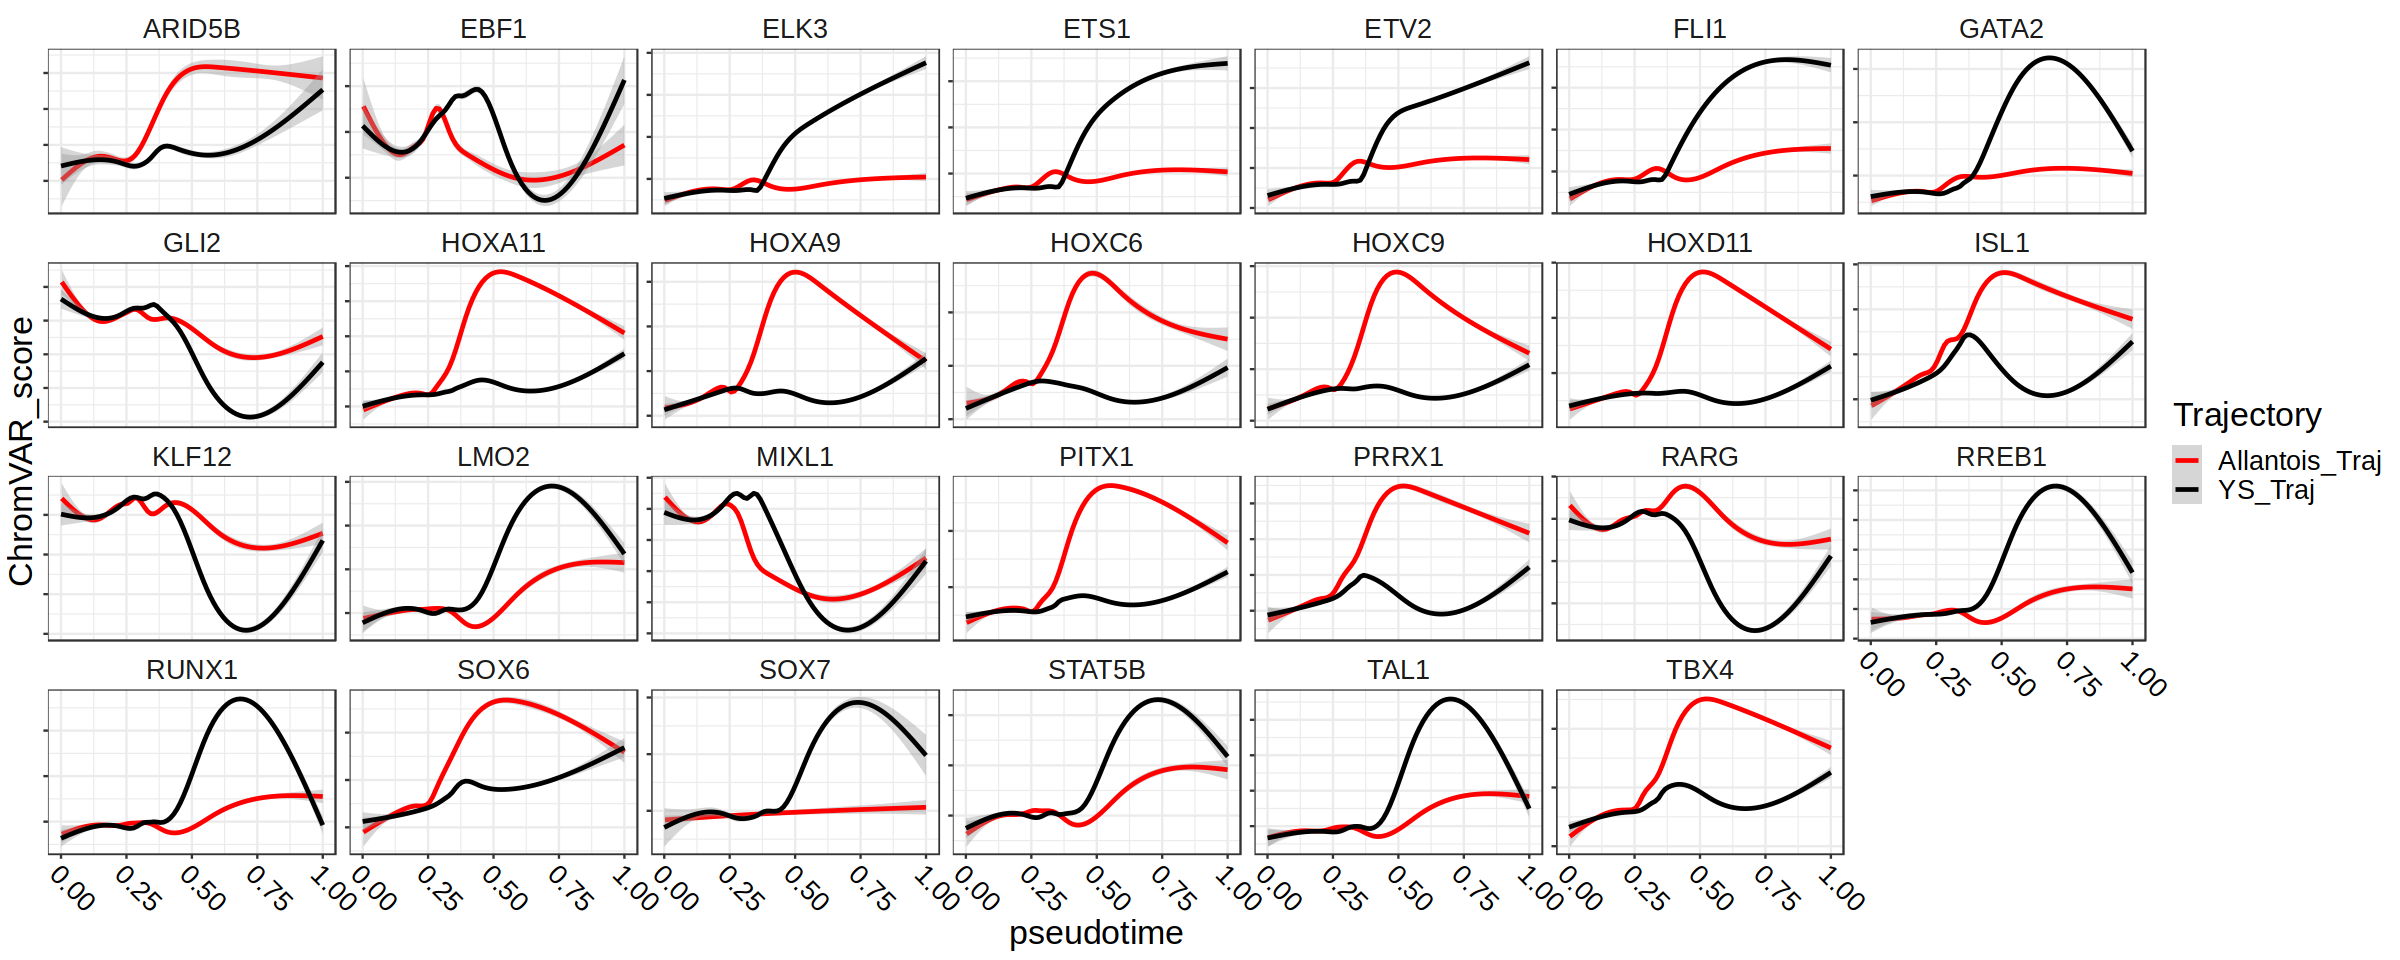

In [76]:
options(repr.plot.height=8, repr.plot.width=20)
ggplot(silicoCISBP_filt.dt, aes(pseudotime, ChromVAR_score, color=Traj)) + 
    #    geom_point(size=0.2, alpha=0.2) + 
        scale_color_manual(values=c(YS_Traj='black', Allantois_Traj='red'), name='Trajectory') + 
        geom_smooth() +
        facet_wrap(~gene, ncol=7, scales='free_y') + 
        theme_bw() + 
        theme(strip.background = element_blank(),
              text = element_text(size=20),
              axis.text = element_text(color='black'),
              axis.text.x = element_text(angle=-45, hjust=0, vjust=1),
              axis.text.y = element_blank())

**General observation:** YS specific TFs first become expressed & then the motif opens up. For the Allantois, the motif opens up first and the TF only gets expressed after

## Search for Enhancers of differential genes

In [8]:
############
## Define functinos
############

# Linking peaks to genes
annotate_peaks = function(gene_metadata.dt = gene_metadata.dt,
                          atac.sce = atac.sce,
                          distance = 1.5e5){
    
    # Load gene metadata
    gene_metadata <- copy(gene_metadata.dt) %>% 
      .[,chr:=as.factor(sub("chr","",chr))] %>%
      setnames("symbol","gene") %>%
      .[, c("chr","start","end","gene","ens_id","strand")]

    peakSet.dt <- data.table(peak = rownames(atac.sce)) %>%
        .[,`:=`(chr = as.factor(peak %>% str_split(':') %>% map_chr(1) %>% gsub('chr', '', .)),
                start = as.integer(peak %>% str_split(':') %>% map_chr(2) %>% str_split('-') %>% map_chr(1)),
                end = as.integer(peak %>% str_split(':') %>% map_chr(2) %>% str_split('-') %>% map_chr(2)))] %>%
        .[,c('chr', 'start', 'end', 'peak')] %>% 
      setkey(chr,start,end)

    ## Overlap 
    gene_metadata.ov <- copy(gene_metadata) %>%
      .[strand=="+",c("gene.start","gene.end"):=list(start,end)] %>%
      .[strand=="-",c("gene.start","gene.end"):=list(end,start)] %>%
      .[strand=="+",c("start","end"):=list (gene.start-distance, gene.end+distance)] %>%
      .[strand=="-",c("end","start"):=list (gene.start+distance, gene.end-distance)] %>% 
      setkey(chr,start,end)

    stopifnot((gene_metadata.ov$end-gene_metadata.ov$start)>0)

    ov <- foverlaps(
      peakSet.dt,
      gene_metadata.ov,
      nomatch = NA
    ) %>%  .[,c("start","end"):=NULL] %>%
      setnames(c("i.start","i.end"),c("peak.start","peak.end")) %>%
      .[,peak.mean:=(peak.start+peak.end)/2] %>%
      # calculate distance from the peak to the genebody
      .[,dist:=min(abs(gene.end-peak.mean), abs(gene.start-peak.mean)), by=c("gene","ens_id","peak","strand")] %>%
      .[strand=="+" & peak.mean>gene.start & peak.mean<gene.end,dist:=0] %>%
      .[strand=="-" & peak.mean<gene.start & peak.mean>gene.end,dist:=0]
    
    return(ov)   
}


# Correlating peaks accessibility with gene expression
cor_acc_gene = function(rna, 
                        atac, 
                        peak_gene_links,
                        correlation_method = "pearson", 
                        cores = detectCores()-2){
    
  gene = unique(peak_gene_links$gene)
    peak_gene_links.dt = mclapply(gene, function(i){
      cat(i, '\n')
      # Get peaks of near gene
      peaks_i <- peak_gene_links[gene==i,peak]

      # calculate correlations between peak accessibility and nearby gene expression
      corr_output <- psych::corr.test(
        x = t(logcounts(rna[i,])), 
        y = t(assay(atac[peaks_i,],"logcounts")), 
        ci = FALSE,
        method = correlation_method
      )

      # create data.table containing cor & pval
      results.dt = data.table(peak = colnames(corr_output$r),
                              cor = round(corr_output$r[1,],3),
                              pval = round(corr_output$p[1,],4)) %>%
  #     .[match(rownames(atac.sce), peak), ] %>% # order peaks by original order
  #     .[,pval := ifelse(peak %in% colnames(corr_output$r), pval, 1)] %>% # Add pvalue = 1 for peaks not in set
       .[,gene := i]

        return(results.dt)
    }, mc.cores=cores) %>% dplyr::bind_rows(.)
    return(peak_gene_links.dt)
}

In [9]:
########
## Find all peaks in 100kb on either end of the differential genes
########
# # Load ATAC data
# atac.sce = readRDS(args$peakmtx)[,meta$cell]
# colData(atac.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

gene_metadata.dt = as.data.table(ArchRProject@geneAnnotation$genes) %>% 
    .[symbol %in% tradeseq_results[sig==TRUE, gene]] %>% 

    setnames(c('seqnames', 'gene_id'), c('chr', 'ens_id'))
genes_peaks = annotate_peaks(gene_metadata.dt = gene_metadata.dt,
                          atac.sce = atac.sce,
                          distance = 1e5)
paste0('Number of linked peaks: ', nrow(genes_peaks[!is.na(gene),]))

[1] "Number of linked peaks: 16539"

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 19740
Number of edges: 604142

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7910
Number of communities: 22
Elapsed time: 3 seconds


[1] "Number of Clusters: 22"

   Mode    TRUE 
logical   19740 

   Mode    TRUE 
logical   19740 

[1] "ATAC statistics: "
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0    30.0    69.0   153.6   162.0  3814.0 


   Mode    TRUE 
logical      22 

[1] "Number of Significant Enhancers: 4234"

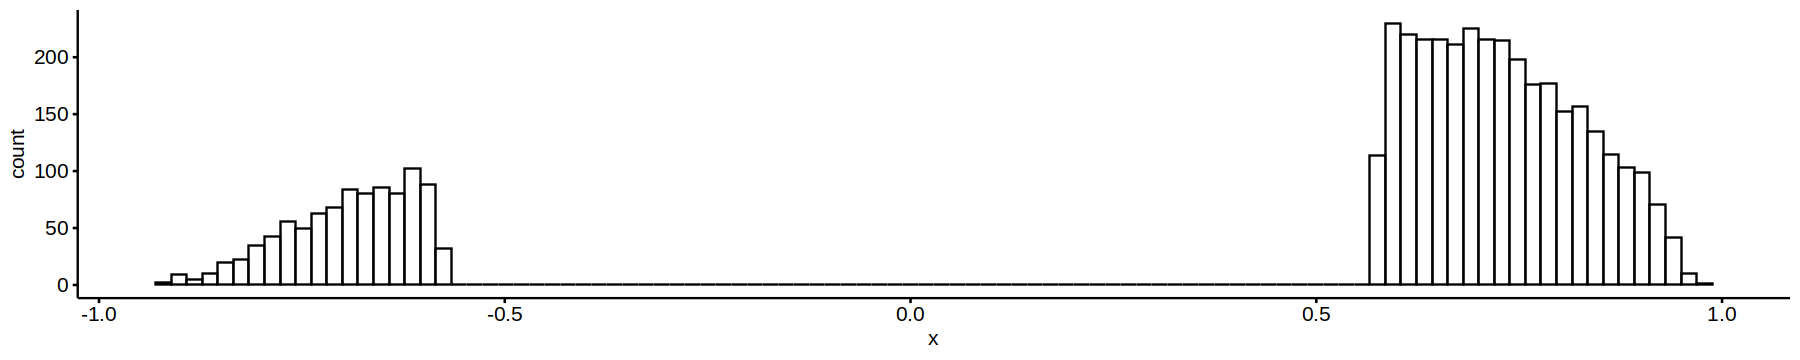

In [10]:
########
## Correlate Accessibility of peaks with Expression of genes
########
# Load meta
meta = fread(args$metadata)[day%in%c('D3', 'D3.5', 'D4', 'D4.5', 'D5') & genotype=='WT']
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

# load mofa factors
mofa = fread(file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/mofa/MOFA_factors.txt.gz')) %>% 
    .[match(colnames(rna.sce), cell),] %>% 
    as.data.frame() %>% tibble::column_to_rownames('cell') %>% 
    as.matrix

# Convert to Seurat
suppressPackageStartupMessages(library(Seurat))
seurat = as.Seurat(rna.sce)
seurat[["mofa"]] <- CreateDimReducObject(embeddings = mofa, key = "mofa_", assay = DefaultAssay(seurat))

# First find high resolution clusters across the whole WT dataset
seurat <- FindNeighbors(seurat, reduction  = 'mofa')
seurat <- FindClusters(seurat, resolution = 1.5)
paste0('Number of Clusters: ', length(unique(Idents(seurat))))

# Subset to peaks to link
atac.sce = atac.sce[unique(genes_peaks[!is.na(gene), peak]),]
# Convert to SCE
atac.sce = as(atac.sce, 'SingleCellExperiment')
assayNames(atac.sce) <- "counts"

# Check if Cells match
summary(colnames(rna.sce) == colnames(atac.sce))
summary(colnames(seurat) == colnames(atac.sce))

# Pseudobulk by cluster
rna.pb = aggregateAcrossCells(rna.sce, id=Idents(seurat), BPPARAM = BPPARAM)
atac.pb = aggregateAcrossCells(atac.sce, id=Idents(seurat), BPPARAM = BPPARAM)

# plot statistics
print('ATAC statistics: ')
print(summary(as.vector(assay(atac.pb, 'counts'))))

rna.sce = rna.sce[,match(colnames(atac.pb), colnames(rna.pb))]
summary(colnames(rna.pb) == colnames(atac.pb))

# Normalise
assay(rna.pb,"logcounts") <- log(1e6*(sweep(assay(rna.pb),2,colSums(assay(rna.pb),na.rm=T),"/"))+1)
assay(atac.pb,"logcounts") <- log(1e6*(sweep(assay(atac.pb),2,colSums(assay(atac.pb),na.rm=T),"/"))+1)

# Calculate peak gene correlation
peak_gene_correlation = cor_acc_gene(rna = rna.pb, 
                        atac = atac.pb, 
                        peak_gene_links = genes_peaks[!is.na(gene)],
                        correlation_method = "pearson", 
                        cores = detectCores()-2) 

options(repr.plot.height=3, repr.plot.width=15)
gghistogram(peak_gene_correlation[pval<0.005, cor], bins=100)
paste0('Number of Significant Enhancers: ', nrow(peak_gene_correlation[pval<0.005, ]))

In [11]:
fwrite(peak_gene_correlation, file.path(args$outdir, 'acc_gene_correlation.txt.gz'))

In [12]:
sign_peaks = acc_gene_correlation[pval<0.05, peak]

ERROR: Error in eval(expr, envir, enclos): object 'acc_gene_correlation' not found


In [ ]:
atac.sce

In [ ]:
atac_filt = atac.sce[sign_peaks,match(rownames(slingshot), colnames(atac.sce))]

In [ ]:
summary(colnames(atac_filt) == rownames(slingshot))
summary(colnames(atac_filt) == rownames(pseudotime))

In [ ]:
#########
## Tradeseq ran in R-script
#########

# # Run trade-seq
# print('Run Trade-seq')
# U <- model.matrix(~atac_filt$replicate)

# sceGAM <- fitGAM(counts = counts(atac_filt),
#                  pseudotime = pseudotime,
#                  cellWeights = pathStats(slingshot)$weights,
#                  U = U,
#                  nknots=8, 
#                  parallel = TRUE,
#                  BPPARAM=BPPARAM,
#                  verbose=T)

# sbatch /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code/rna_atac/trajectory/run_traj1_vs_traj2_ATAC.sh

[1] "Run Trade-seq"
  |                                                                      |   0%

In [14]:
sceGAM = readRDS(file.path(args$outdir, 'sceGAM_WT_Traj1_vs_Traj2_ATAC.rds'))

In [15]:
sceGAM

class: SingleCellExperiment 
dim: 6962 8146 
metadata(1): tradeSeq
assays(1): counts
rownames(6962): chr1:12636732-12637332 chr1:12690581-12691181 ...
  chrX:168672343-168672943 chrX:168674033-168674633
rowData names(1): tradeSeq
colnames(8146): 2_Eo_DEG_G9_day3_5_VC#AAACAGCCAAAGCGGC-1
  2_Eo_DEG_G9_day3_5_VC#AAACAGCCAACCTAAT-1 ...
  rv_eo_deg_day4_control#TTTAACGAGTGAGAGC-1
  rv_eo_deg_day4_control#TTTCATCAGTCAGGCC-1
colData names(2): crv tradeSeq
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

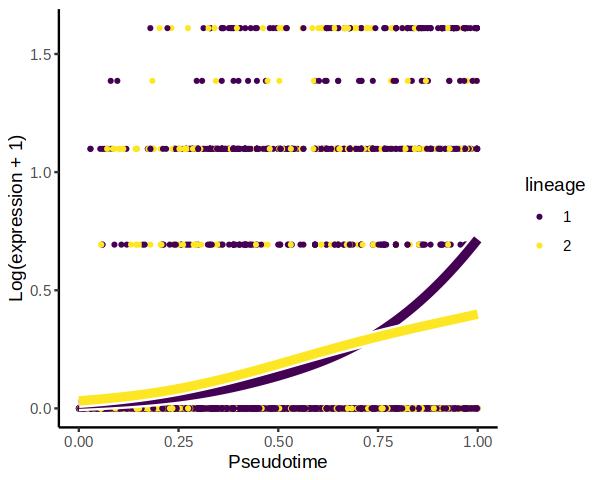

In [16]:
options(repr.plot.height=4, repr.plot.width=5)

startRes <- startVsEndTest(sceGAM)
oStart <- order(startRes$waldStat, decreasing = TRUE)
sigGeneStart <- names(sceGAM)[oStart[1]]
plotSmoothers(sceGAM, counts(sceGAM), gene = sigGeneStart)

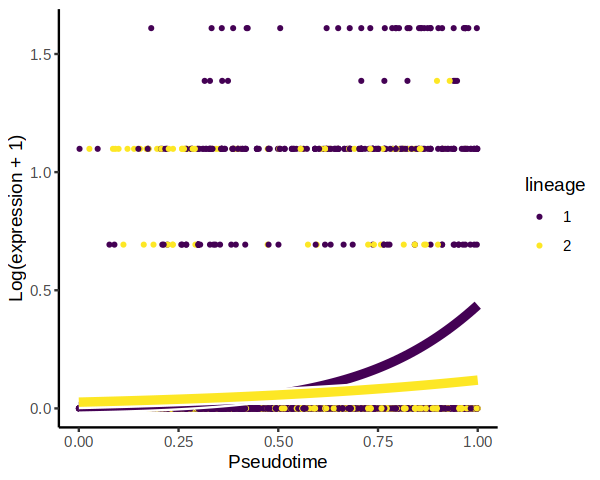

In [17]:
sigGeneStart <- names(sceGAM)[oStart[3]]
plotSmoothers(sceGAM, counts(sceGAM), gene = sigGeneStart)

In [18]:
earlyDERes <- earlyDETest(sceGAM, knots = c(1, 4))
oEarly <- order(earlyDERes$waldStat, decreasing = TRUE)

In [19]:
genes_keep = earlyDERes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>%
    .[,padj:= p.adjust(pvalue, "fdr")] %>%
    .[,sig:=ifelse(padj<=0.05, TRUE, FALSE)] #%>%
    #.[order(padj, -waldStat)]

In [20]:
nrow(genes_keep[sig==TRUE])

[1] 1965

In [21]:
endRes <- diffEndTest(sceGAM, l2fc=log2(1.5))
genes_keep = endRes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>%
    .[,padj:= p.adjust(pvalue, "fdr")] %>%
    .[,sig:=ifelse(padj<=0.05, TRUE, FALSE)]
nrow(genes_keep[sig==TRUE])

[1] 296

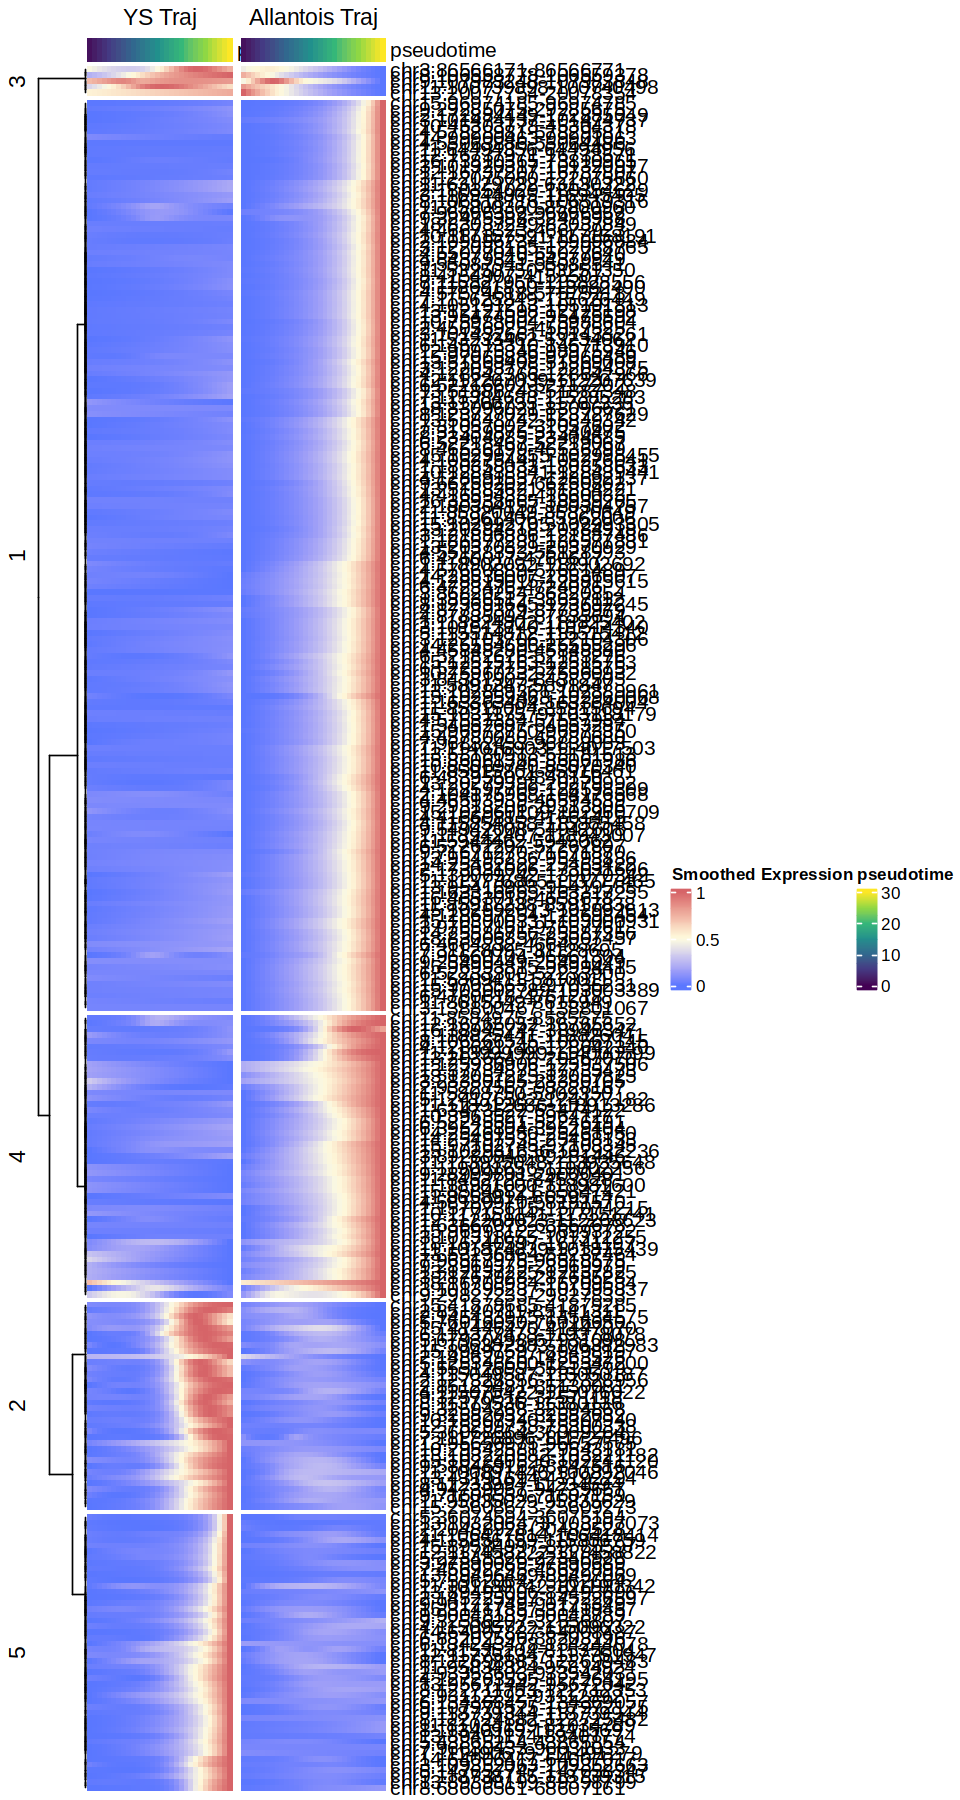

In [22]:
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(ComplexHeatmap))

trans <- div_gradient_pal(low='#5a77ff', mid='lightyellow', high='#d66468')
cols <- trans(seq(0,1, length.out=20))
col_fun = colorRamp2(seq(0, 30, 5), viridis::viridis(length(seq(0, 30, 5))))
ha = HeatmapAnnotation(pseudotime = 1:30,
                       col = list(pseudotime = col_fun))

yhatSmooth <- predictSmooth(sceGAM, gene = genes_keep[sig==TRUE]$gene, nPoints = 30, tidy = FALSE)

# minmax normalisation 
minmax = function(x){(x-min(x))/(max(x)-min(x))}
yhatSmooth_minmax = t(apply(yhatSmooth, 1, minmax)) 

WT = yhatSmooth_minmax[, grepl('lineage1', colnames(yhatSmooth_minmax))]
KO = yhatSmooth_minmax[, grepl('lineage2', colnames(yhatSmooth_minmax))]

# Clustering
k = 5
group = kmeans(yhatSmooth_minmax, centers = k)$cluster
row_clust = cluster_within_group(t(yhatSmooth_minmax), group)

hm_list = Heatmap(WT, 
                  cluster_rows = row_clust,
                  cluster_columns = FALSE,
                  column_title = 'YS Traj',
                  show_column_names  = FALSE,
                  row_split = k,
                  #row_split = as.data.frame(group), 
                  #km = 6,
                  col = cols,
                  heatmap_legend_param = list(title = 'Smoothed Expression'), 
                  top_annotation = ha) + 
          Heatmap(KO, 
                  cluster_columns = FALSE, 
                  column_title = 'Allantois Traj',
                  show_column_names  = FALSE,
                  col = cols,
                  show_heatmap_legend = F, 
                  top_annotation = ha)
options(repr.plot.height=15, repr.plot.width=8)
draw(hm_list)

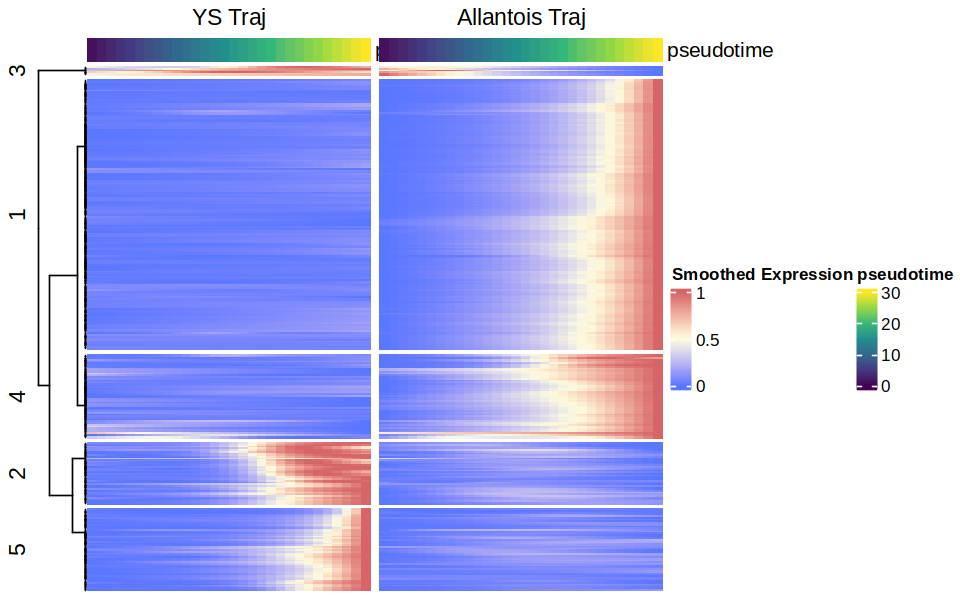

In [23]:
hm_list = Heatmap(WT, 
                  cluster_rows = row_clust,
                  cluster_columns = FALSE,
                  column_title = 'YS Traj',
                  show_column_names  = FALSE,
                  row_split = k,
                  #row_split = as.data.frame(group), 
                  #km = 6,
                  col = cols,
                  heatmap_legend_param = list(title = 'Smoothed Expression'), 
                  top_annotation = ha) + 
          Heatmap(KO, 
                  cluster_columns = FALSE, 
                  column_title = 'Allantois Traj',
                  show_column_names  = FALSE,
                  show_row_names  = FALSE,
                  col = cols,
                  show_heatmap_legend = F, 
                  top_annotation = ha)

options(repr.plot.height=5, repr.plot.width=8)
draw(hm_list)

In [24]:
smooth.dt = as.data.table(yhatSmooth_minmax, keep.rownames=T) %>% 
    setnames('rn', 'gene') %>% 
    melt(., id.vars = 'gene', variable.names = 'column', value.names= 'value') %>%
    .[,trajectory := ifelse(grepl('lineage1', variable), 'YS_traj', 'Allantois_Traj')] %>%
    .[,trajectory := factor(trajectory, levels=c('YS_traj', 'Allantois_Traj'))] 

In [25]:
# Now combine clusters together in a single plot
smooth.dt = as.data.table(yhatSmooth_minmax, keep.rownames=T) %>% 
    setnames('rn', 'gene') %>% 
    melt(., id.vars = 'gene', variable.names = 'column', value.names= 'value') %>%
    .[,trajectory := ifelse(grepl('lineage1', variable), 'YS_traj', 'Allantois_Traj')] %>%
    .[,trajectory := factor(trajectory, levels=c('YS_traj', 'Allantois_Traj'))] %>%
    .[,pseudotime := as.numeric(str_split(variable, '_') %>% map_chr(2))] %>% 
    merge(., 
          as.data.table(group, keep.rownames=T) %>% setnames('rn', 'gene'),
          by='gene') 

mean.dt = smooth.dt %>% copy() %>% 
    .[,value := mean(value), by=c('group', 'trajectory', 'pseudotime')] %>% 
    unique(by=c('group', 'trajectory', 'pseudotime'))

nrow(smooth.dt)
nrow(mean.dt)

[1] 17760

[1] 300

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


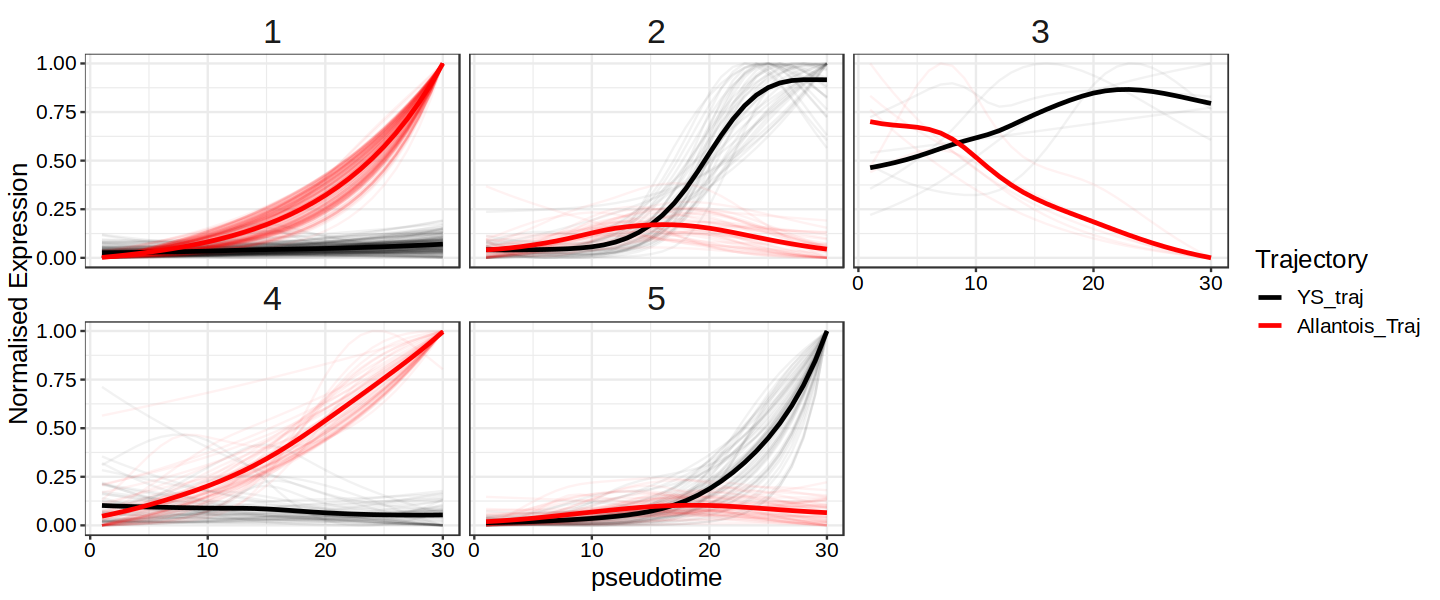

In [26]:
options(repr.plot.height=5, repr.plot.width=12)
ggplot(smooth.dt, aes(pseudotime, value, col=trajectory, group.by=gene)) + 
    geom_line(alpha=0.05, size=0.5) +
    geom_line(data=mean.dt, size=1) + 
    scale_color_manual(values=c('YS_traj' = 'black', 'Allantois_Traj' = 'red'), name='Trajectory') + 
    facet_wrap(~group) + 
    ylab('Normalised Expression') + 
    theme_bw() + 
    theme(strip.background=element_blank(),
          strip.text = element_text(size=20), 
         text = element_text(size=15, color='black'),
         axis.text = element_text(color='black'))

In [ ]:
# Find way to plot individual genes with each enhancer as well

In [27]:
sce_filt

class: SingleCellExperiment 
dim: 32285 13465 
metadata(0):
assays(2): counts logcounts
rownames(32285): Xkr4 Gm1992 ... AC234645.1 AC149090.1
rowData names(0):
colnames(13465): 2_Eo_DEG_G9_day3_5_VC#AAACAGCCAAAGCGGC-1
  2_Eo_DEG_G9_day3_5_VC#AAACAGCCAACCTAAT-1 ...
  rv_eo_deg_day4_control#TTTGTGGCATCCCTCA-1
  rv_eo_deg_day4_control#TTTGTGTTCCTGAATA-1
colData names(26): barcode sample ... mofa_cluster celltype_v1
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [28]:
atac.sce

class: SingleCellExperiment 
dim: 15535 19740 
metadata(0):
assays(1): counts
rownames(15535): chr1:12610245-12610845 chr1:12622951-12623551 ...
  chrX:168673233-168673833 chrX:168674033-168674633
rowData names(1): idx
colnames(19740): 1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1
  1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1 ...
  rv_eo_deg_day4_control#TTTGTGGCATCCCTCA-1
  rv_eo_deg_day4_control#TTTGTGTTCCTGAATA-1
colData names(26): barcode sample ... mofa_cluster celltype_v1
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [31]:
head(pseudotime)

,Lineage2,Lineage3
2_Eo_DEG_G9_day3_5_VC#AAACAGCCAAAGCGGC-1,0.3200646,0.2286171
2_Eo_DEG_G9_day3_5_VC#AAACAGCCAACCTAAT-1,0.3485502,0.2934838
2_Eo_DEG_G9_day3_5_VC#AAACAGCCATGGAGGC-1,0.3139919,0.2882544
2_Eo_DEG_G9_day3_5_VC#AAACAGCCATGTTGGC-1,0.3629003,0.2971743
2_Eo_DEG_G9_day3_5_VC#AAACATGCAAGCGATG-1,0.3667776,0.2689133
2_Eo_DEG_G9_day3_5_VC#AAACATGCACCACAAC-1,0.3705742,0.2741409


In [32]:
head(peak_gene_correlation)

peak,cor,pval,gene
<chr>,<dbl>,<dbl>,<chr>
chr1:12610245-12610845,0.361,0.0991,Sulf1
chr1:12622951-12623551,-0.306,0.1658,Sulf1
chr1:12636732-12637332,0.721,0.0002,Sulf1
chr1:12689405-12690005,0.219,0.3278,Sulf1
chr1:12690581-12691181,0.805,0.0000,Sulf1
chr1:12692125-12692725,0.958,0.0000,Sulf1


In [34]:
atac.sce

class: SingleCellExperiment 
dim: 15535 19740 
metadata(0):
assays(1): counts
rownames(15535): chr1:12610245-12610845 chr1:12622951-12623551 ...
  chrX:168673233-168673833 chrX:168674033-168674633
rowData names(1): idx
colnames(19740): 1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1
  1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1 ...
  rv_eo_deg_day4_control#TTTGTGGCATCCCTCA-1
  rv_eo_deg_day4_control#TTTGTGTTCCTGAATA-1
colData names(26): barcode sample ... mofa_cluster celltype_v1
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [53]:
unique(peak_gene_correlation$gene)

[1] "Sulf1"      "Paqr8"      "Aff3"       "Hecw2"      "Plcl1"     
  [6] "Aox1"       "Adam23"     "Cdh20"      "Gli2"       "Lypd1"     
 [11] "Hmcn1"      "Npl"        "Rasal2"     "Prrx1"      "Creg1"     
 [16] "F11r"       "Itpkb"      "Mixl1"      "Tgfb2"      "Plxna2"    
 [21] "Plekhg1"    "Syne1"      "Sash1"      "Nhsl1"      "Sgk1"      
 [26] "Rspo3"      "Popdc3"     "Bves"       "Arid5b"     "Mmp11"     
 [31] "Chst11"     "Gnptab"     "Elk3"       "Lgr5"       "Frs2"      
 [36] "Nxph4"      "Esyt1"      "Aebp1"      "Tns3"       "Ccdc85a"   
 [41] "Ebf1"       "Flt4"       "Fstl4"      "Trim11"     "Pmp22"     
 [46] "Hs3st3b1"   "Hs3st3a1"   "Gas7"       "Scarf1"     "Asic2"     
 [51] "Tbx4"       "Tom1l1"     "Abi3"       "Stat5b"     "Ramp2"     
 [56] "Dusp3"      "Icam2"      "Sdk2"       "Syngr2"     "Rbfox3"    
 [61] "Greb1"      "Tspan13"    "Nova1"      "Prkch"      "Kcnh5"     
 [66] "Rhoj"       "Vrtn"       "Syndig1l"   "Pgf"        "Flrt2"     
 [71] "Eml5"       "Kif26a"     "Rapgef5"    "Itgb8"      "Ryr2"      
 [76] "Elmo1"      "Ripor2"     "Slc22a23"   "Rreb1"      "Bmp6"      
 [81] "Phactr1"    "Gadd45g"    "Ror2"       "Pitx1"      "Adcy2"     
 [86] "Edil3"      "Hapln1"     "Vcan"       "F2rl1"      "F2r"       
 [91] "Iqgap2"     "Enc1"       "Mast4"      "Isl1"       "Fgf10"     
 [96] "Zmiz1"      "Wnt5a"      "Ccnb1ip1"   "Slc7a8"     "Sox7"      
[101] "Nefl"       "Lcp1"       "Klf12"      "Mbnl2"      "Slc1a3"    
[106] "Pdzd2"      "Myo10"      "Ankrd33b"   "Zfpm2"      "Oxr1"      
[111] "Col22a1"    "Celsr1"     "Shank3"     "Slc38a4"    "Hdac7"     
[116] "Rarg"       "Hoxc9"      "Hoxc6"      "Hoxc4"      "Vasn"      
[121] "Rbfox1"     "St6gal1"    "Igsf11"     "Robo2"      "Runx1"     
[126] "Efna5"      "Ptprm"      "Cdh2"       "Zfp516"     "Cyp26a1"   
[131] "Fgf8"       "Cacnb2"     "Etl4"       "Notch1"     "Egfl7"     
[136] "Ncs1"       "Dnm1"       "Ggta1"      "Zeb2"       "Fmnl2"     
[141] "Cobll1"     "Galnt3"     "Hoxd11"     "Aplnr"      "Tspan18"   
[146] "Cd44"       "Lmo2"       "Cd59a"      "Lgr4"       "Inafm2"    
[151] "Frmd5"      "Dusp2"      "Adra2b"     "Sirpa"      "Prnp"      
[156] "Bmp2"       "Slc24a3"    "Cd40"       "Kcnb1"      "Bmp7"      
[161] "Cables2"    "Tnik"       "Lhfp"       "Mme"        "Fhdc1"     
[166] "Lrba"       "Thbs3"      "Efna1"      "Plekho1"    "Pde4dip"   
[171] "Igsf3"      "Vav3"       "Frrs1"      "Arhgap29"   "Sec24d"    
[176] "Col25a1"    "Tspan5"     "Cntfr"      "Stra6l"     "Coro2a"    
[181] "Grin3a"     "Zfp462"     "Pakap"      "Svep1"      "Brinp1"    
[186] "Ccdc171"    "Bnc2"       "Mllt3"      "Tek"        "Patj"      
[191] "L1td1"      "Plpp3"      "Tal1"       "Mob3c"      "Gja4"      
[196] "Phc2"       "Atp13a2"    "Cdk6"       "Sema3a"     "Reln"      
[201] "Zfp512"     "Yes1"       "Sorcs2"     "Cd38"       "Atp8a1"    
[206] "Kdr"        "Adgrl3"     "Slc4a4"     "Lrrc8c"     "Tgfbr3"    
[211] "Pla2g1b"    "Pitpnm2"    "Scarb1"     "Pdgfa"      "Flt1"      
[216] "Sgce"       "Ica1"       "Zc3hav1"    "Braf"       "Hoxa9"     
[221] "Hoxa10"     "Hoxa11"     "Gata2"      "Trh"        "Cntn3"     
[226] "Plxnd1"     "Wnt5b"      "Cd9"        "Etv6"       "Rassf8"    
[231] "Slc1a5"     "Etv2"       "Gramd1a"    "Vsig10l"    "Rasip1"    
[236] "Tenm4"      "Dchs1"      "Scube2"     "Galnt18"    "Sox6"      
[241] "Ifitm3"     "Fgf3"       "Evi5l"      "Col4a2"     "Sfrp1"     
[246] "Dusp4"      "Acsl1"      "Csgalnact1" "Chd9"       "Exoc3l"    
[251] "Cdh3"       "Cbfa2t3"    "Rhou"       "Kcnk1"      "Bmper"     
[256] "Eepd1"      "Ntm"        "Fli1"       "Ets1"       "Cadm1"     
[261] "Chrna3"     "Chrnb4"     "Neo1"       "Herc1"      "Myzap"     
[266] "Cgnl1"      "Lrrc1"      "Ctsh"       "Slc9a9"     "Inka1"     
[271] "Tdgf1"      "Itga9"      "Spin2c"     "Nhs"        "Gpm6b"     
[276] "Frmpd4"

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


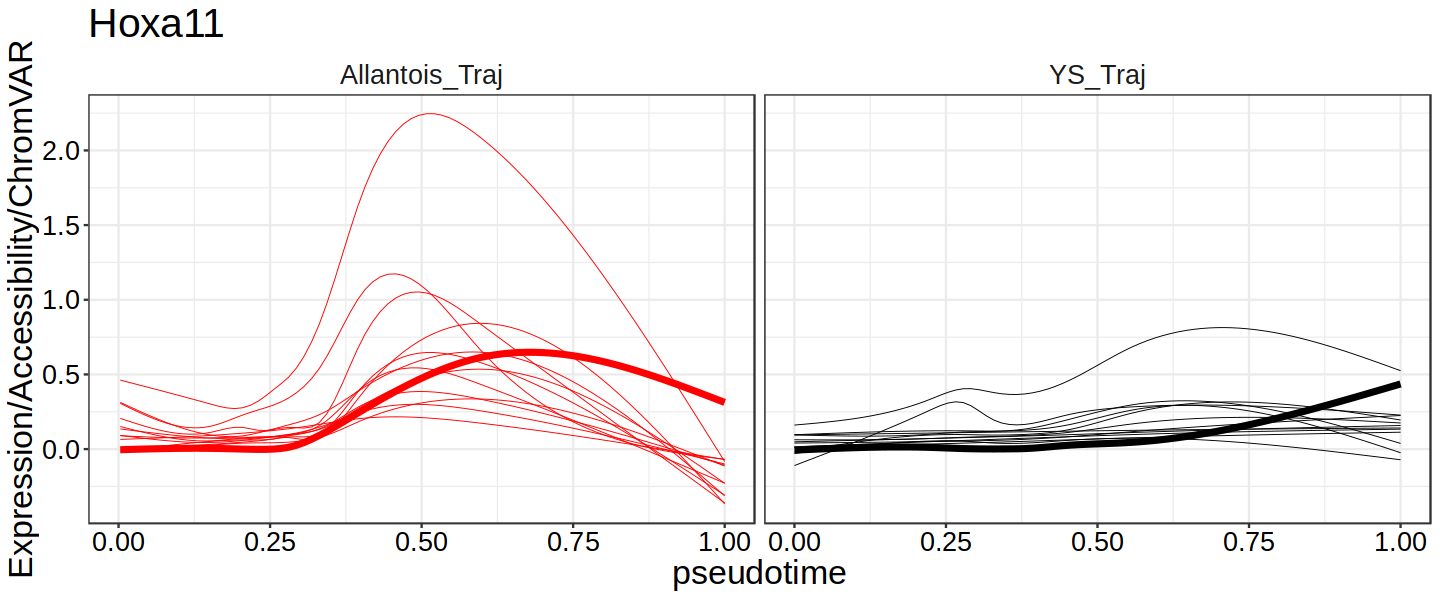

In [152]:
genei = 'Hoxa11'
rna.tmp = sce_filt[genei,]
atac.tmp = atac.sce[peak_gene_correlation[gene==genei & peak %in% genes_keep[padj<=0.3, gene], peak],]

# Get ChromVAR along trajectories
test.dt = as.data.table(t(as.matrix(assay(atac.tmp))),keep.rownames=T) %>% 
    setnames('rn', 'cell') %>% 
    merge(., Traj_full, by='cell') %>%  # Add pseudotime & trajectory
    melt(., id.vars = c("cell", "pseudotime", "Traj"), # wide to long
               variable.name = "gene", value.name = "Accessibility")# %>% 
  #  .[,Accessibility:=minmax(Accessibility)]

# Get ChromVAR along trajectories
test2.dt = as.data.table(t(as.matrix(assay(rna.tmp))),keep.rownames=T) %>% 
    setnames('rn', 'cell') %>% 
    merge(., Traj_full, by='cell') %>%  # Add pseudotime & trajectory
    melt(., id.vars = c("cell", "pseudotime", "Traj"), # wide to long
               variable.name = "gene", value.name = "Accessibility")# %>% 
  #  .[,Accessibility:=minmax(Accessibility)]

ggplot(test.dt, aes(pseudotime, Accessibility, color=Traj, group.by=gene)) + 
    geom_smooth(size=0.2, se=F) + 
   # geom_point(size=0.1) + 
    geom_smooth(data = test2.dt, size=1.5, se=F) +
    # geom_smooth(data = silicoCISBP_filt.dt %>% copy() %>% 
    #                 .[gene == str_to_upper(genei),] %>% 
    #                 .[, Accessibility:=ChromVAR_score], size= 1.5, linetype ="longdash", se=F) +
    scale_color_manual(values=c(Allantois_Traj='red', YS_Traj='black'), name='Trajectory') + 
    ggtitle(genei) + 
    ylab('Expression/Accessibility/ChromVAR') + 
    facet_wrap(~Traj) + 
    theme_bw() + 
    theme(text = element_text(size=20),
         axis.text=element_text(color='black'),
         strip.background=element_blank(),
         legend.position='none')

In [45]:
head(Traj_full)

cell,pseudotime,Traj
<chr>,<dbl>,<chr>
2_Eo_DEG_G9_day3_5_VC#AAACAGCCAAAGCGGC-1,0.3200646,YS_Traj
2_Eo_DEG_G9_day3_5_VC#AAACAGCCAACCTAAT-1,0.3485502,YS_Traj
2_Eo_DEG_G9_day3_5_VC#AAACAGCCATGGAGGC-1,0.3139919,YS_Traj
2_Eo_DEG_G9_day3_5_VC#AAACAGCCATGTTGGC-1,0.3629003,YS_Traj
2_Eo_DEG_G9_day3_5_VC#AAACATGCACCACAAC-1,0.3705742,YS_Traj
2_Eo_DEG_G9_day3_5_VC#AAACATGCAGAATGAC-1,0.2220541,YS_Traj


In [ ]:
ggplot(pseudotime, aes(Lineage2, ))

In [30]:
genes_keep[sig==TRUE]

gene,waldStat,df,pvalue,logFC1_2,padj,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
chr1:38636512-38637112,12.189205,1,4.806685e-04,-1.874273,1.724956e-02,TRUE
chr1:54052687-54053287,11.372590,1,7.453586e-04,-2.491184,2.348462e-02,TRUE
chr1:55512699-55513299,13.848317,1,1.981742e-04,3.176623,8.844158e-03,TRUE
chr1:63473522-63474122,11.502530,1,6.950154e-04,-1.921178,2.261074e-02,TRUE
chr1:63667078-63667678,11.254834,1,7.941591e-04,-1.367920,2.446432e-02,TRUE
chr1:118824802-118825402,13.312472,1,2.636465e-04,-1.817600,1.119212e-02,TRUE
chr1:118825441-118826041,14.108516,1,1.725607e-04,-1.994505,8.117350e-03,TRUE
chr1:118902092-118902692,50.295824,1,1.322276e-12,-2.316329,1.534280e-09,TRUE
chr1:118942407-118943007,20.058207,1,7.512045e-06,-2.328149,8.716476e-04,TRUE


## ArchR

In [26]:
# Functions
plot_enr_heatmap = function(enrichMotifs, ntop=25) {
    heatmapEM <- plotEnrichHeatmap(enrichMotifs, n = ntop, returnMatrix = TRUE)

    enriched.dt = melt(as.data.table(heatmapEM, keep.rownames=T) %>% setnames('rn', 'TF'), id.vars = c("TF")) %>%
        .[order(-value)] %>% .[,TF:=strsplit(TF, '_') %>% map_chr(1)]

    keep_tfs = enriched.dt %>% .[,variable:=factor(variable, levels=opts$celltype_levels )] %>% .[order(variable)] %>% .[, head(.SD, ntop),  by=variable] %>% .$TF   
    enriched.dt = enriched.dt[TF %in% keep_tfs] %>% .[order( -value)] %>% 
        #.[,TF:=strsplit(TF, '_') %>% map_chr(1)] %>%
         .[,TF:=factor(TF, levels=unique(keep_tfs))] %>%
        .[,variable:=factor(variable, levels=opts$celltype_levels )]
    
    p = ggplot(enriched.dt, aes(TF, variable, fill=value)) + 
    geom_tile(col='black') +
    scale_fill_gradient(low='white', high='darkblue', name='Norm. Enrichment -log10(P-adj) [0-max]') +
    theme_void() + theme(text=element_text(size=15), 
                         axis.text.x=element_text(angle=-90,hjust=0,vjust=0.5, size=15), 
                         axis.text.y=element_text(hjust=0),
                        legend.position='bottom')
p
    return(p)
}

In [29]:
ArchRProject@peakAnnotation$silicoChIP_CISBP = list(Name = 'silicoChIP_CISBP',
                                            motifs = NA,
                                            Positions = "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/Annotations/silicoChIP_CISBP-Positions-In-Peaks.rds",
                                             Matches = "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR/Annotations/silicoChIP_CISBP-Matches-In-Peaks.rds")

#### Trajectory 2

In [34]:
Trajectory2 <- getMarkerFeatures(
  ArchRProj = ArchRProject, 
  useMatrix = "PeakMatrix",
  groupBy = "celltype_v1",
  testMethod = "wilcoxon",
  bias = c("TSSEnrichment", "log10(nFrags)"),
  useGroups = "Posterior_Mes",
  bgdGroups = "Primitive_Streak",
    verbose = False
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-3e3a8c100c1a0c-Date-2023-12-07_Time-11-20-23.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Integer.Matrix

2023-12-07 11:20:23 : Matching Known Biases, 0.004 mins elapsed.

2023-12-07 11:20:24 : Computing Pairwise Tests (1 of 1), 0.022 mins elapsed.

Pairwise Test Posterior_Mes : Seqnames chr1

Pairwise Test Posterior_Mes : Seqnames chr10

Pairwise Test Posterior_Mes : Seqnames chr11

Pairwise Test Posterior_Mes : Seqnames chr12

Pairwise Test Posterior_Mes : Seqnames chr13

Pairwise Test Posterior_Mes : Seqnames chr14

Pairwise Test Posterior_Mes : Seqnames chr15

Pairwise Test Posterior_Mes : Seqnames chr16

Pairwise Test Posterior_Mes : Seqnames chr17

Pairwise Test Posterior_Mes : Seqnames chr18

Pairwise Test Posterior_Mes : Seqnames chr19

Pairwise Test Posterior_Mes : Seqnames chr2

Pairwise Test Posterior_Mes : Seqnames chr3

Pairwise Test Posterior_Mes : Seqnames chr4

Pairwise Test Po

In [35]:
Trajectory2

class: SummarizedExperiment 
dim: 234908 1 
metadata(2): MatchInfo Params
assays(7): Log2FC Mean ... AUC MeanBGD
rownames(234908): 1 2 ... 234907 234908
rowData names(4): seqnames idx start end
colnames(1): Posterior_Mes
colData names(0):

Warning message:
“'markerPlot' is deprecated.
Use 'plotMarkers' instead.
See help("Deprecated")”
Warning message:
“Removed 140 rows containing missing values (`geom_point_rast()`).”


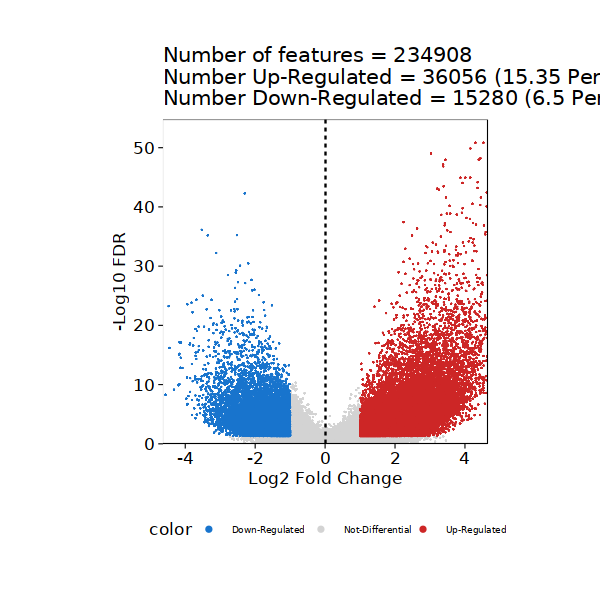

In [36]:
pma <- markerPlot(seMarker = Trajectory2, name = "Posterior_Mes", cutOff = "FDR <= 0.05 & abs(Log2FC) >= 1", plotAs = "Volcano")
pma

ArchR logging to : ArchRLogs/ArchR-peakAnnoEnrichment-3e3a8c757e98cd-Date-2023-12-07_Time-11-21-41.log
If there is an issue, please report to github with logFile!

2023-12-07 11:21:47 : Computing Enrichments 1 of 1, 0.107 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-peakAnnoEnrichment-3e3a8c757e98cd-Date-2023-12-07_Time-11-21-41.log

ArchR logging to : ArchRLogs/ArchR-peakAnnoEnrichment-3e3a8c1a09183-Date-2023-12-07_Time-11-21-48.log
If there is an issue, please report to github with logFile!

2023-12-07 11:21:54 : Computing Enrichments 1 of 1, 0.108 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-peakAnnoEnrichment-3e3a8c1a09183-Date-2023-12-07_Time-11-21-48.log



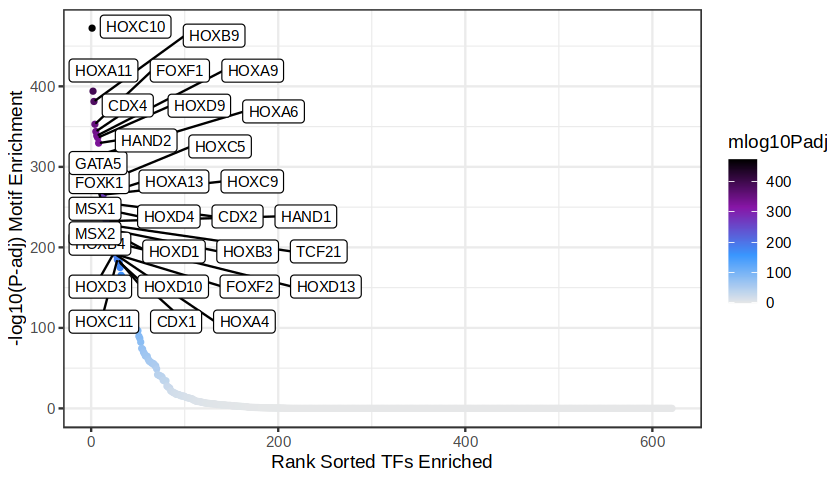

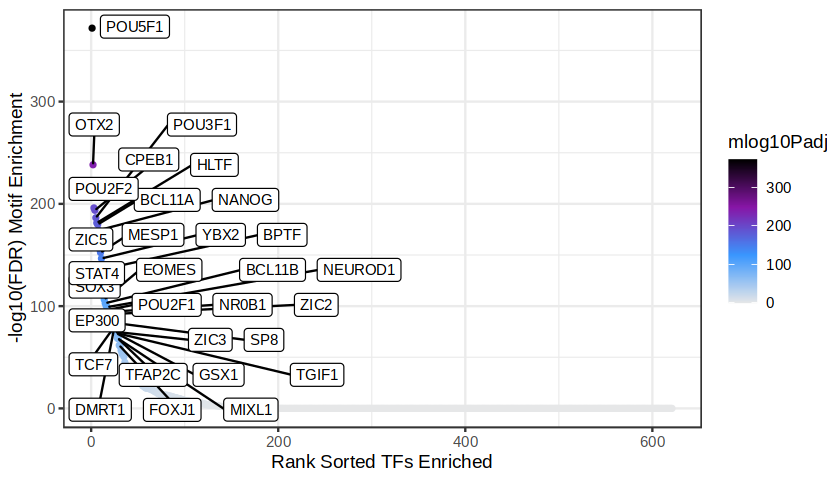

In [37]:
options(repr.plot.height=4, repr.plot.width=7)

motifsUp <- peakAnnoEnrichment(
    seMarker = Trajectory2,
    ArchRProj = ArchRProject,
    peakAnnotation = "silicoChIP_CISBP",
    cutOff = "FDR <= 0.05 & Log2FC >= 1"
  )

df <- data.frame(TF = rownames(motifsUp), mlog10Padj = assay(motifsUp)[,1])
df <- df[order(df$mlog10Padj, decreasing = TRUE),]
df$rank <- seq_len(nrow(df))

ggUp <- ggplot(df, aes(rank, mlog10Padj, color = mlog10Padj)) + 
  geom_point(size = 1) +
  ggrepel::geom_label_repel(
        data = df[rev(seq_len(30)), ], aes(x = rank, y = mlog10Padj, label = TF), 
        size = 3,
        nudge_x = 2,
        color = "black",
          max.overlaps = Inf
  ) + theme_ArchR() + 
  ylab("-log10(P-adj) Motif Enrichment") + 
  xlab("Rank Sorted TFs Enriched") +
  scale_color_gradientn(colors = paletteContinuous(set = "comet"))+ 
    theme_bw()

ggUp

motifsDo <- peakAnnoEnrichment(
    seMarker = Trajectory2,
    ArchRProj = ArchRProject,
    peakAnnotation = "silicoChIP_CISBP",
    cutOff = "FDR <= 0.05 & Log2FC <= -1"
  )

df <- data.frame(TF = rownames(motifsDo), mlog10Padj = assay(motifsDo)[,1])
df <- df[order(df$mlog10Padj, decreasing = TRUE),]
df$rank <- seq_len(nrow(df))

ggDo <- ggplot(df, aes(rank, mlog10Padj, color = mlog10Padj)) + 
  geom_point(size = 1) +
  ggrepel::geom_label_repel(
        data = df[rev(seq_len(30)), ], aes(x = rank, y = mlog10Padj, label = TF), 
        size = 3,
        nudge_x = 2,
        color = "black",
          max.overlaps = Inf
  ) + theme_ArchR() + 
  ylab("-log10(FDR) Motif Enrichment") +
  xlab("Rank Sorted TFs Enriched") +
  scale_color_gradientn(colors = paletteContinuous(set = "comet")) + 
    theme_bw()

ggDo

In [74]:
markerList <- rbind(as.data.table(getMarkers(Trajectory2, cutOff = "FDR <= 0.01 & Log2FC >= 1")[[1]], keep.rownames=T), 
                    as.data.table(getMarkers(Trajectory2, cutOff = "FDR <= 0.01 & Log2FC <= -1")[[1]], keep.rownames=T)) %>% 
            .[,peak:=paste0(seqnames, ':', start, '-', end)]

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”
Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [75]:
head(markerList)

rn,seqnames,idx,start,end,Log2FC,FDR,MeanDiff,peak
<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
93339,chr17,1031,12669053,12669653,4.956904,1.798084e-55,0.3115452,chr17:12669053-12669653
175528,chr5,13401,139174295,139174895,5.771800,8.355823e-52,0.2723615,chr5:139174295-139174895
59039,chr13,2908,43146332,43146932,4.300190,1.422713e-51,0.2810871,chr13:43146332-43146932
222375,chr9,4656,54783874,54784474,4.529131,1.422713e-51,0.2854928,chr9:54783874-54784474
216117,chr8,11100,121359263,121359863,4.156648,1.368602e-50,0.3257032,chr8:121359263-121359863
166580,chr5,4453,66915796,66916396,3.030146,9.261234e-50,0.2842733,chr5:66915796-66916396


In [310]:
slingshot = readRDS(file.path(args$outdir, 'slingshot.rds'))

In [311]:
T2_cells =  as.data.table(pathStats(slingshot[,3])$pseudotime, keep.rownames=T)[!is.na(Lineage3)]$rn

In [312]:
T2.sce = atac.sce[markerList$peak, T2_cells]

In [313]:
T2_slingshot = slingshot[T2_cells,]

In [314]:
summary(colnames(T2.sce) == rownames(T2_slingshot))
summary(colnames(T2.sce) == T2_cells)

   Mode    TRUE 
logical   17282 

   Mode    TRUE 
logical   17282 

In [315]:
#############################
## ATAC TFIDF normalisation ##
#############################

atac_tfidf.mtx <- tfidf(assay(T2.sce), method=1, scale.factor=1e4)

In [343]:
pseudobin.dt = data.table(cell = rownames(T2_slingshot),
            pseudobin = cut(assay(T2_slingshot)[, 'Lineage3'], breaks = seq(0, max(assay(T2_slingshot)[, 'Lineage3']+1), 0.3))) %>%
            .[!is.na(pseudobin)]

In [345]:
pseudobinned.mtx = lapply(unique(pseudobin.dt$pseudobin)[order(unique(pseudobin.dt$pseudobin))], function(i){
        cells = pseudobin.dt[pseudobin == i, cell]
        if(length(cells)>2){
            tmp.mtx = as.matrix(rowMeans(atac_tfidf.mtx[,cells]))
            colnames(tmp.mtx) = i
            return(tmp.mtx) 
        }
})  %>% 
    do.call('cbind', .)
pseudobinned.mtx = pseudobinned.mtx[,-ncol(pseudobinned.mtx)]

In [346]:
# minmax normalisation 
minmax = function(x){(x-min(x))/(max(x)-min(x))}
pseudobinned.mtx_minmax = t(apply(pseudobinned.mtx, 1, minmax)) 

In [347]:
# Clustering
k = 20
group = kmeans(pseudobinned.mtx_minmax, centers = k)$cluster
row_clust = cluster_within_group(t(pseudobinned.mtx_minmax), group)

In [348]:
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(ComplexHeatmap))

x = ncol(pseudobinned.mtx_minmax)

trans <- div_gradient_pal(low='#5a77ff', mid='lightyellow', high='#d66468')
cols <- trans(seq(0,1, length.out=x))
col_fun = colorRamp2(seq(0, x, 5), viridis::viridis(length(seq(0, x, 5))))
ha = HeatmapAnnotation(pseudotime = 1:x,
                       col = list(pseudotime = col_fun))


`use_raster` is automatically set to TRUE for a matrix with more than
2000 rows. You can control `use_raster` argument by explicitly setting
TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



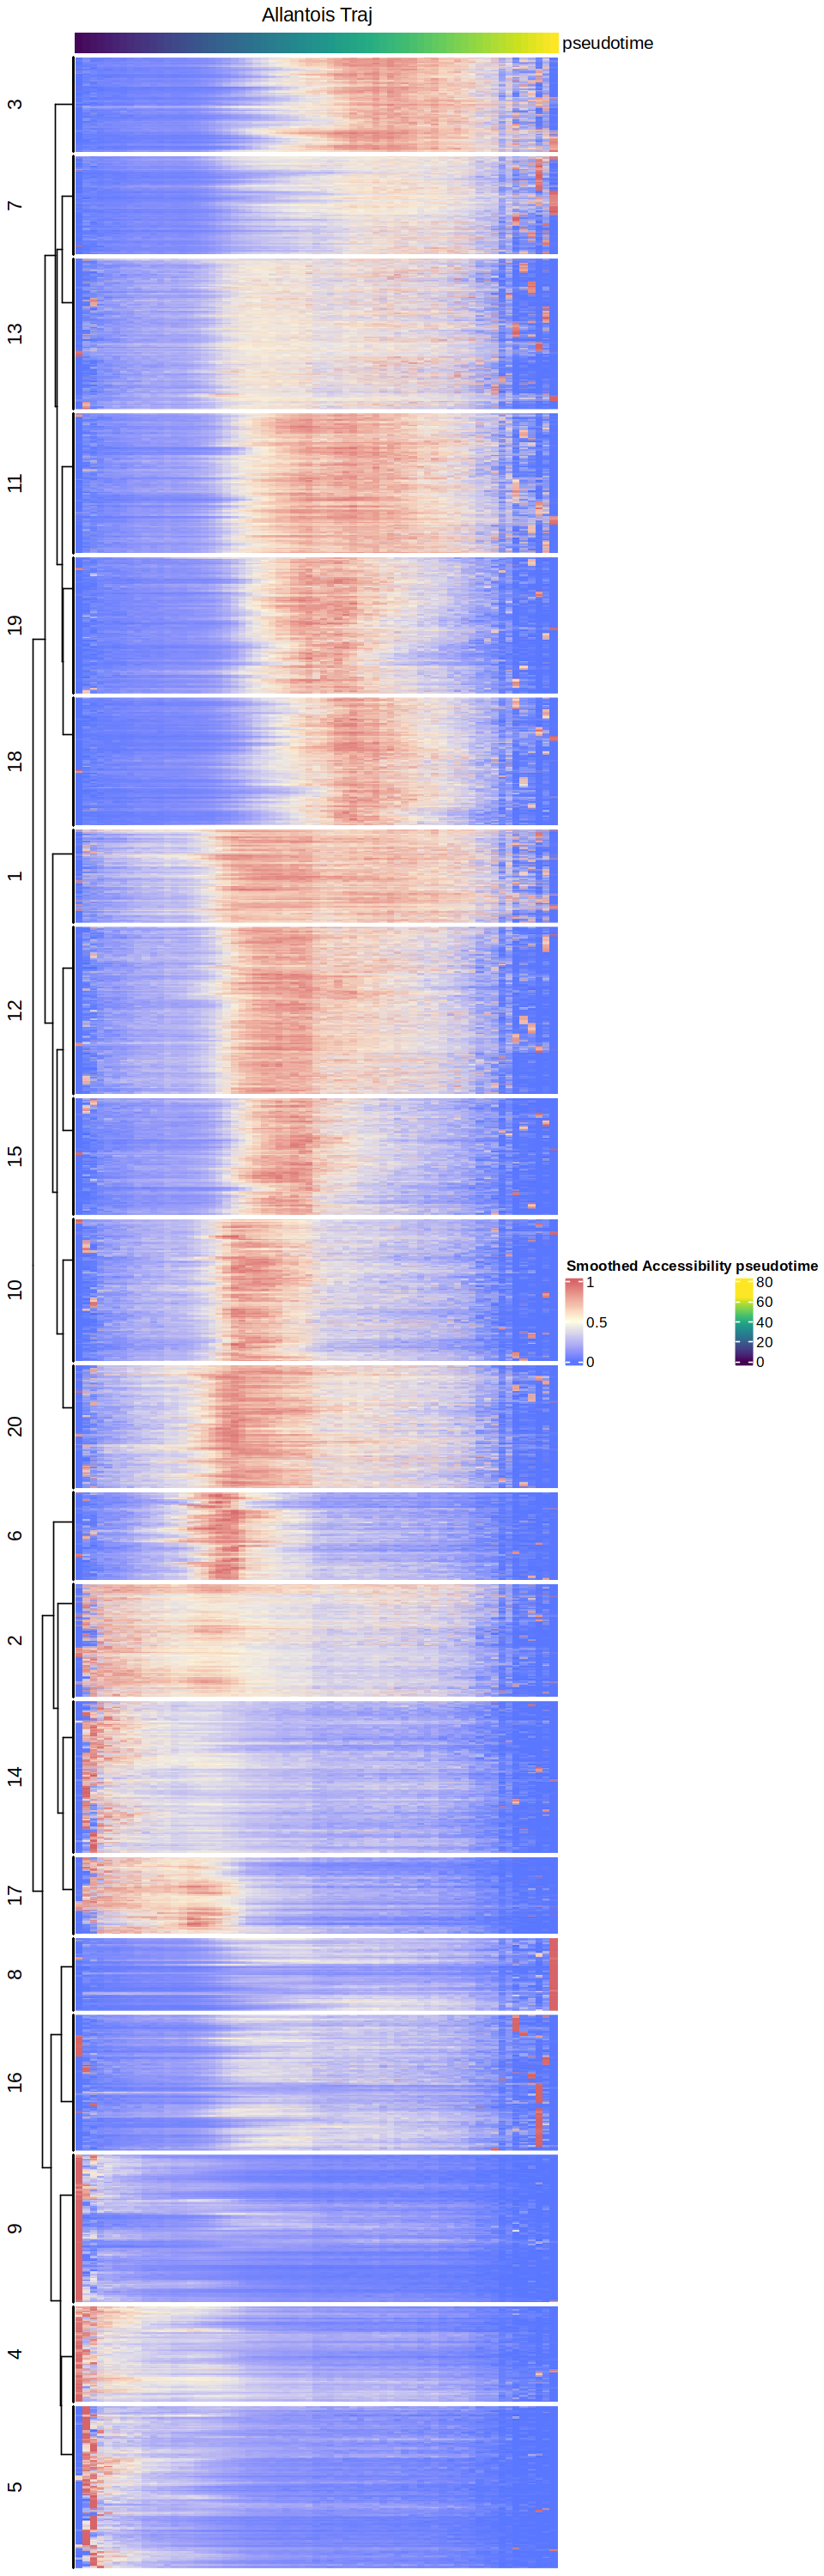

In [349]:

hm_list = Heatmap(pseudobinned.mtx_minmax, 
                  cluster_rows = row_clust,
                  cluster_columns = FALSE,
                  column_title = 'Allantois Traj',
                  show_column_names  = FALSE,,
                show_row_names  = FALSE,
                  row_split = k,
                  #row_split = as.data.frame(group), 
                  #km = 6,
                  col = cols,
                  heatmap_legend_param = list(title = 'Smoothed Accessibility'), 
                  top_annotation = ha)
options(repr.plot.height=25, repr.plot.width=8)
draw(hm_list)

In [350]:
head(pseudobinned.mtx_minmax)

,"(0,0.3]","(0.3,0.6]","(0.6,0.9]","(0.9,1.2]","(1.2,1.5]","(1.5,1.8]","(1.8,2.1]","(2.1,2.4]","(2.4,2.7]","(2.7,3]",⋯,"(16.5,16.8]","(16.8,17.1]","(17.1,17.4]","(17.4,17.7]","(17.7,18]","(18,18.3]","(18.3,18.6]","(18.6,18.9]","(18.9,19.2]","(19.2,19.5]"
chr17:12669053-12669653,0,0.07385527,0.06805353,0.009504201,0.09182909,0.03299669,0.08425924,0.05763600,0.09418915,0.10457149,⋯,0.51923853,0.85905933,0.8279875,0.6408641,0.8208192,0.5203978,0.6095764,0.4412513,1.0000000,0.9124778
chr5:139174295-139174895,0,0.00000000,0.16929517,0.027906773,0.02414300,0.00000000,0.03797828,0.03676783,0.03825984,0.07807429,⋯,0.47825770,0.63480363,0.5222971,0.6704538,0.9570516,0.2880792,0.1349050,0.3253303,1.0000000,0.4650676
chr13:43146332-43146932,0,0.13191830,0.02420755,0.022123539,0.01282297,0.04877175,0.06418212,0.08966026,0.11124164,0.14852013,⋯,0.54925910,0.50708828,0.5155584,0.3600951,0.1364841,0.7203227,1.0000000,0.6729613,0.8813094,0.6478432
chr9:54783874-54784474,0,0.00000000,0.00000000,0.023961354,0.06160243,0.00000000,0.05710724,0.15539774,0.13071667,0.20467806,⋯,0.57333814,0.93219209,0.3739968,0.5579334,0.5278637,0.7507881,0.3282141,0.7899614,0.7081321,0.0000000
chr8:121359263-121359863,0,0.07227450,0.04112698,0.061887654,0.06485171,0.02834326,0.04871332,0.02311952,0.09370895,0.05870439,⋯,0.47152548,0.45508623,0.2850221,0.7945568,0.5822249,0.4067390,0.1542126,0.3610828,0.4018609,1.0000000
chr5:66915796-66916396,0,0.00000000,0.00000000,0.036106240,0.06731255,0.03842397,0.03186798,0.20472787,0.21267287,0.24853442,⋯,0.04342321,0.04004226,0.0000000,0.0000000,0.6763876,0.0000000,0.0000000,0.0000000,0.1992088,0.0000000


In [360]:
# Now combine clusters together in a single plot
smooth.dt = as.data.table(pseudobinned.mtx_minmax, keep.rownames=T) %>% 
    setnames('rn', 'gene') %>% 
    melt(., id.vars = 'gene', variable.names = 'column', value.names= 'value') %>% 
    .[,pseudotime := variable] %>% 
    merge(., 
          as.data.table(group, keep.rownames=T) %>% setnames('rn', 'gene'),
          by='gene') 

mean.dt = smooth.dt %>% copy() %>% 
    .[,value := mean(value), by=c('group', 'pseudotime')] %>% 
    unique(by=c('group', 'pseudotime'))

nrow(smooth.dt)
nrow(mean.dt)

[1] 2399345

[1] 1300

In [364]:
head(pseudobin.dt)

cell,pseudobin
<chr>,<fct>
2_Eo_DEG_G9_day3_5_VC#AAACAGCCAAAGCGGC-1,"(4.5,4.8]"
2_Eo_DEG_G9_day3_5_VC#AAACAGCCAACCTAAT-1,"(6,6.3]"
2_Eo_DEG_G9_day3_5_VC#AAACAGCCATGGAGGC-1,"(6,6.3]"
2_Eo_DEG_G9_day3_5_VC#AAACAGCCATGTTGGC-1,"(6,6.3]"
2_Eo_DEG_G9_day3_5_VC#AAACATGCAAGCGATG-1,"(5.4,5.7]"
2_Eo_DEG_G9_day3_5_VC#AAACATGCAGAATGAC-1,"(4.2,4.5]"


In [361]:
head(smooth.dt)

gene,variable,value,pseudotime,group
<chr>,<fct>,<dbl>,<fct>,<int>
chr10:100031506-100032106,"(0,0.3]",0.0000000,"(0,0.3]",12
chr10:100031506-100032106,"(0.3,0.6]",0.0000000,"(0.3,0.6]",12
chr10:100031506-100032106,"(0.6,0.9]",0.7051607,"(0.6,0.9]",12
chr10:100031506-100032106,"(0.9,1.2]",0.0000000,"(0.9,1.2]",12
chr10:100031506-100032106,"(1.2,1.5]",0.4546366,"(1.2,1.5]",12
chr10:100031506-100032106,"(1.5,1.8]",0.4239231,"(1.5,1.8]",12


In [365]:
head(smooth.dt$variable)

[1] (0,0.3]   (0.3,0.6] (0.6,0.9] (0.9,1.2] (1.2,1.5] (1.5,1.8]
65 Levels: (0,0.3] (0.3,0.6] (0.6,0.9] (0.9,1.2] (1.2,1.5] ... (19.2,19.5]

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observat

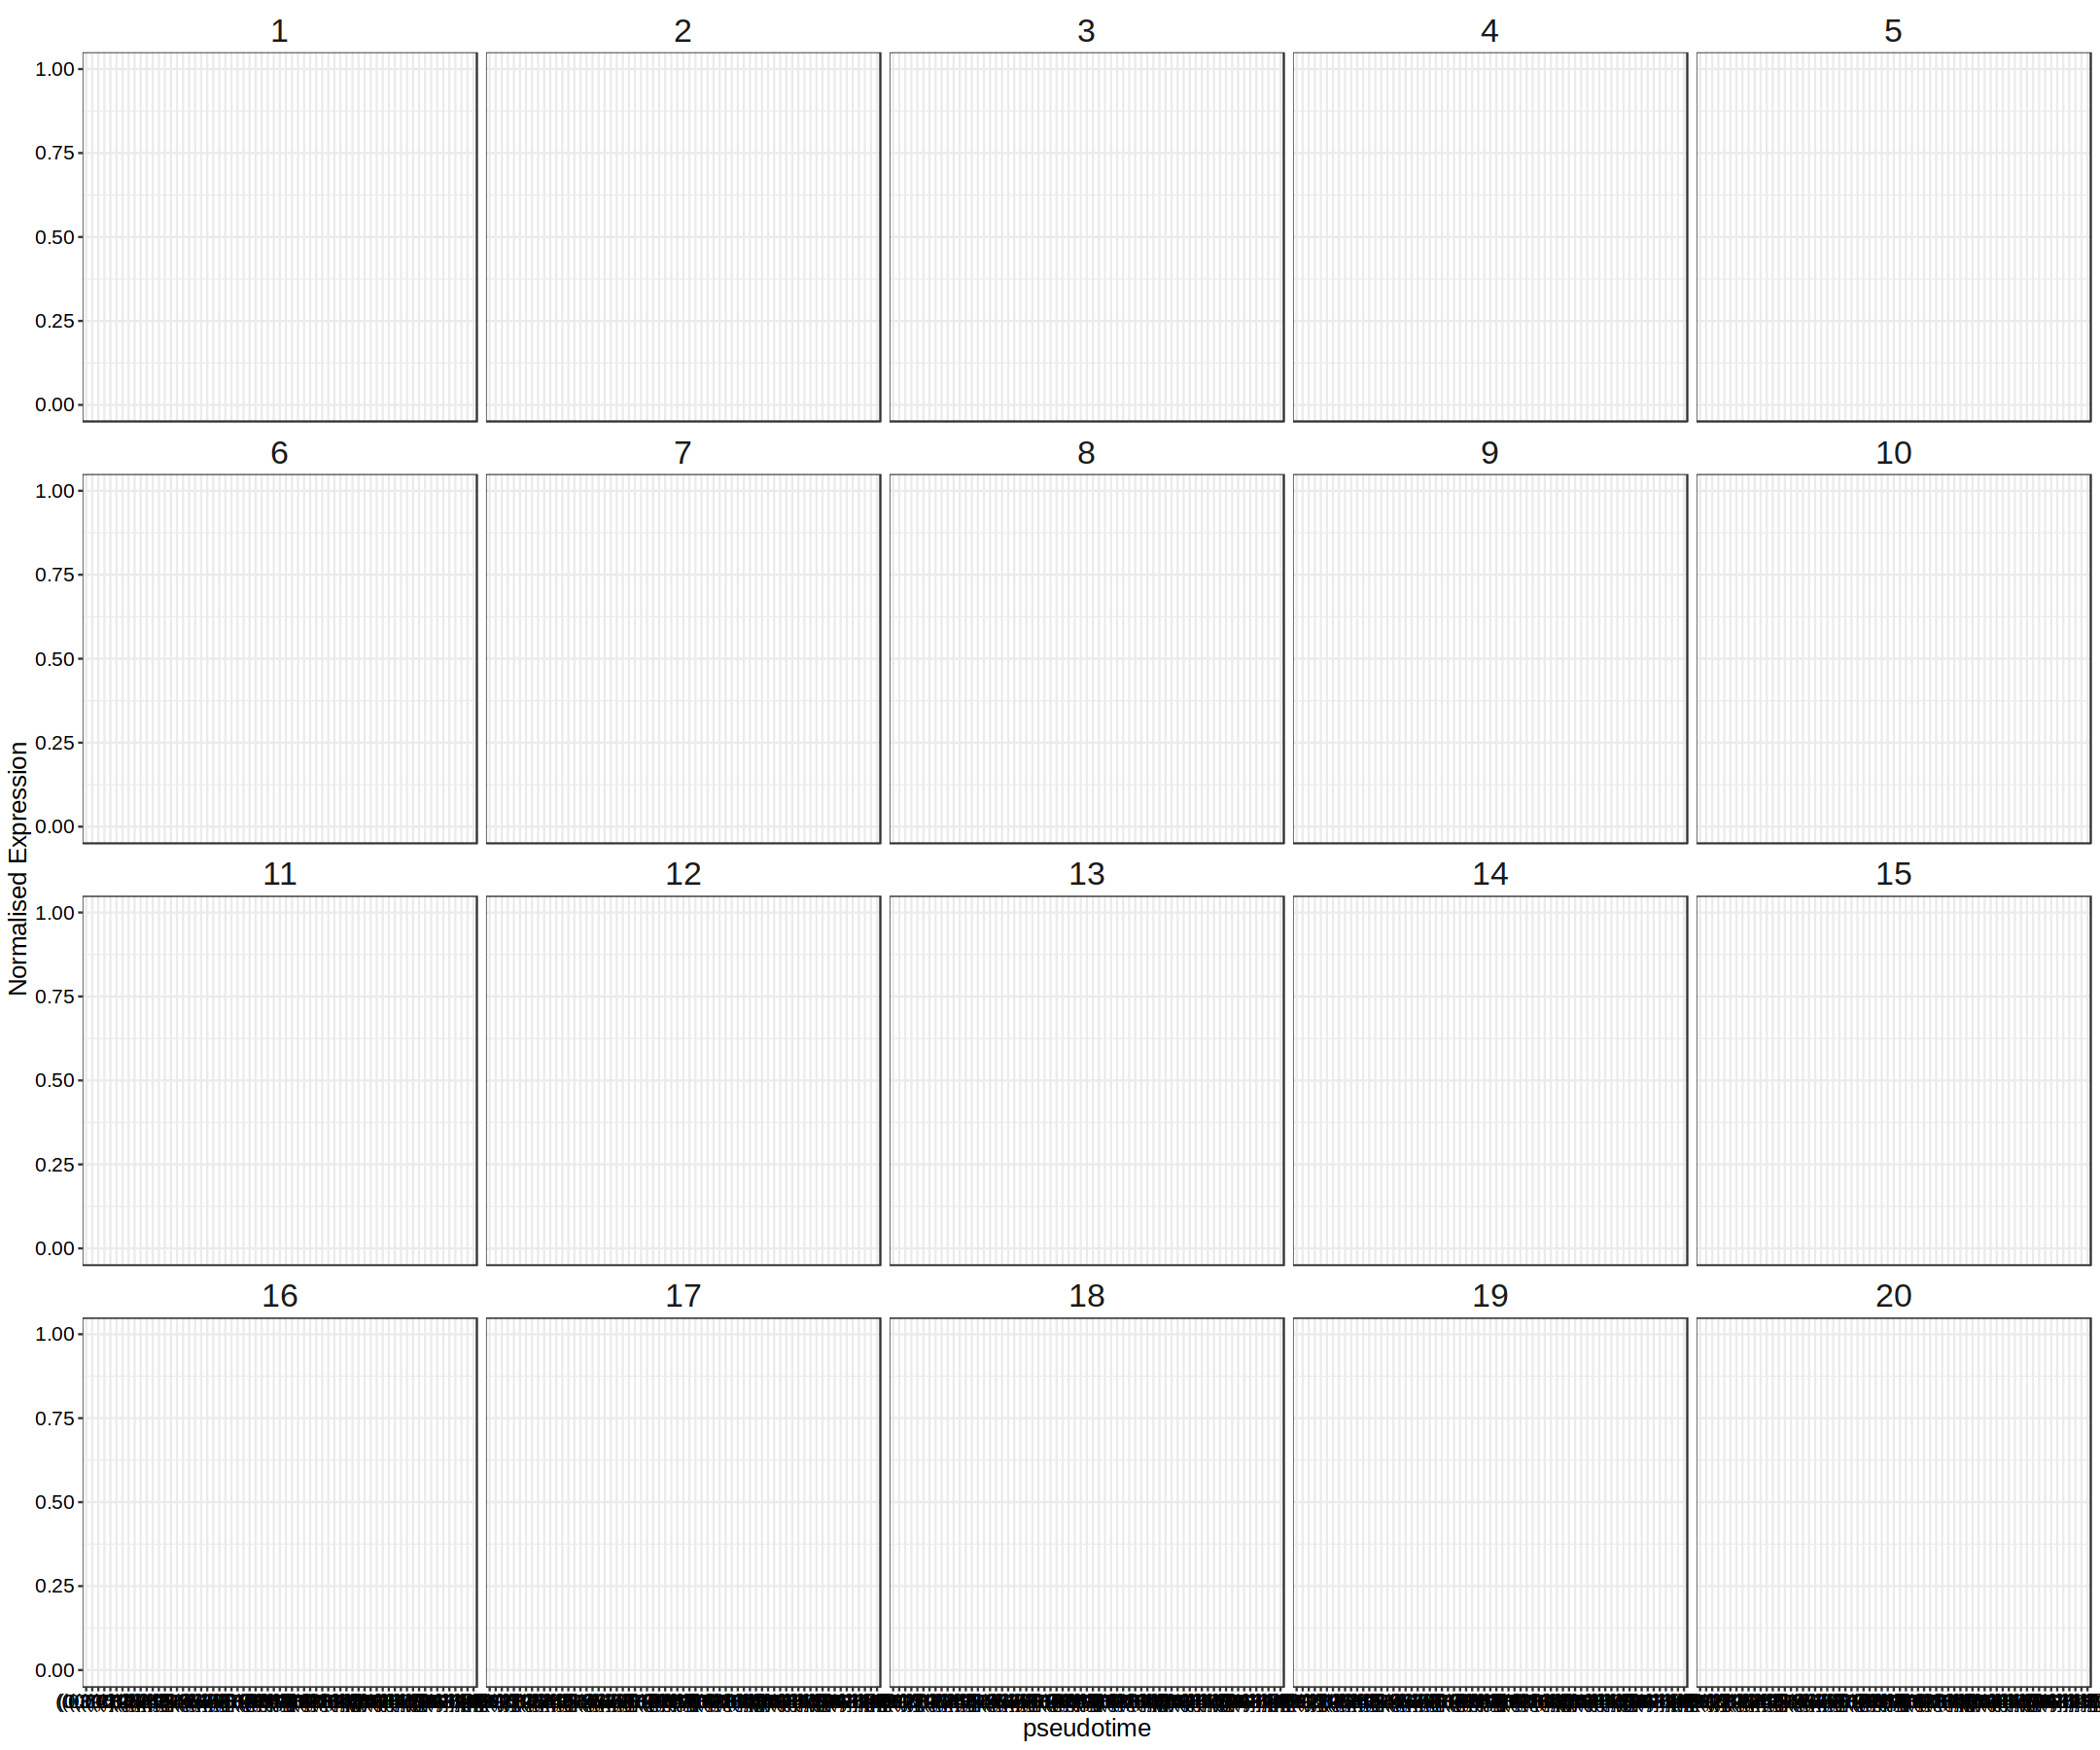

In [363]:
options(repr.plot.height=15, repr.plot.width=18)
ggplot(smooth.dt, aes(pseudotime, value, group.by=gene)) + 
    geom_line(alpha=0.05, size=0.8) +
    geom_line(data=mean.dt, size=1, color='red') + 
    facet_wrap(~group) + 
    ylab('Normalised Expression') + 
    theme_bw() + 
    theme(strip.background=element_blank(),
          strip.text = element_text(size=20), 
         text = element_text(size=15, color='black'),
         axis.text = element_text(color='black'))

In [ ]:
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(ComplexHeatmap))

trans <- div_gradient_pal(low='#5a77ff', mid='lightyellow', high='#d66468')
cols <- trans(seq(0,1, length.out=20))
col_fun = colorRamp2(seq(0, 30, 5), viridis::viridis(length(seq(0, 30, 5))))
ha = HeatmapAnnotation(pseudotime = 1:30,
                       col = list(pseudotime = col_fun))

yhatSmooth <- predictSmooth(sceGAM, gene = genes_keep[sig==TRUE]$gene, nPoints = 30, tidy = FALSE)

# minmax normalisation 
minmax = function(x){(x-min(x))/(max(x)-min(x))}
yhatSmooth_minmax = t(apply(yhatSmooth, 1, minmax)) 

WT = yhatSmooth_minmax[, grepl('lineage1', colnames(yhatSmooth_minmax))]
KO = yhatSmooth_minmax[, grepl('lineage2', colnames(yhatSmooth_minmax))]

# Clustering
k = 15
group = kmeans(yhatSmooth_minmax, centers = k)$cluster
row_clust = cluster_within_group(t(yhatSmooth_minmax), group)

hm_list = Heatmap(WT, 
                  cluster_rows = row_clust,
                  cluster_columns = FALSE,
                  column_title = 'YS Traj',
                  show_column_names  = FALSE,
                  row_split = k,
                  #row_split = as.data.frame(group), 
                  #km = 6,
                  col = cols,
                  heatmap_legend_param = list(title = 'Smoothed Expression'), 
                  top_annotation = ha) + 
          Heatmap(KO, 
                  cluster_columns = FALSE, 
                  column_title = 'Allantois Traj',
                  show_column_names  = FALSE,
                  col = cols,
                  show_heatmap_legend = F, 
                  top_annotation = ha)
options(repr.plot.height=25, repr.plot.width=8)
draw(hm_list)

In [269]:
head(b[[1]])

,"(4,5]"
chr17:12669053-12669653,0.09682515
chr5:139174295-139174895,0.12836157
chr13:43146332-43146932,0.30801710
chr9:54783874-54784474,0.19310285
chr8:121359263-121359863,0.18387969
chr5:66915796-66916396,0.70937827


In [319]:
test = data.table(cell = T2_cells,
                  pseudotime = assay(T2_slingshot)[, 'Lineage3'],
                  weight = pathStats(T2_slingshot)$weights[, 'Lineage3'],
                  accessibility = frollmean(atac_tfidf.mtx[1,], 20, 0))

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


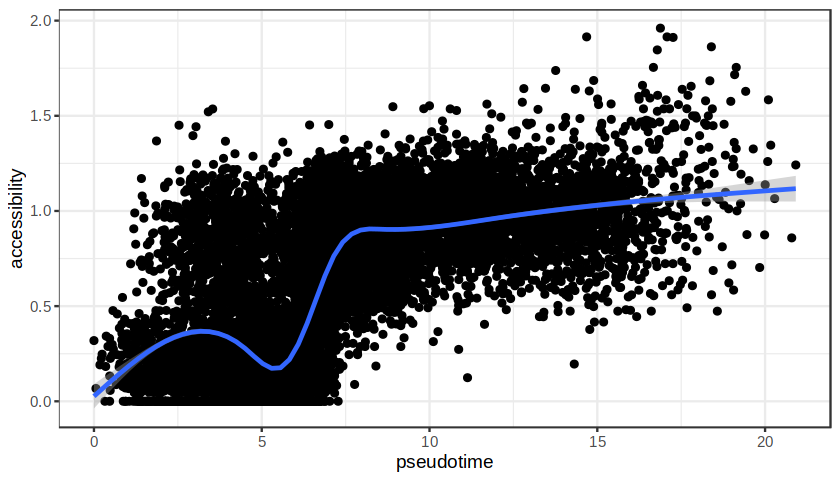

In [320]:
p = ggplot(test, aes(pseudotime, accessibility)) + 
    geom_point() + 
    geom_smooth() + 
    theme_bw()
p

In [240]:
pseudotime = test$pseudotime
pseudotime = matrix(pseudotime, nrow = length(pseudotime))
y =  t(matrix(atac_tfidf.mtx[1,], nrow = length(atac_tfidf.mtx[1,])))
cellWeights = matrix(test$weight, nrow = length(test$weight))

In [241]:
tradeSeq:::.fitGAM(y, conditions= NULL, pseudotime= test$pseudotime, cellWeights = test$weight)

TMM normalization failed. Will use unnormalized library sizesas offset.


Some library sizes are zero. Offsetting these to 1.


Warning message in min(which(!is.na(SigmaAll))):
“no non-missing arguments to min; returning Inf”


ERROR: Error in UseMethod("predict"): no applicable method for 'predict' applied to an object of class "NULL"
